# Машинное обучение 1. Домашнее задание 3

## Генерация признаков

В работе решается задача предсказания победы Radiant в Dota 2. Основная метрика — Gini: $2 \cdot ROC	ext{-}AUC - 1$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

from hw3_utils import (
    AUCExtractor,
    HeroesEmbedder,
    TrendExtractor,
    WinrateEmbedder,
    add_match_features,
    evaluate_pipeline,
    feature_selection_grid,
    gini,
    load_optional_csv,
    make_logreg_pipeline,
    split_feature_columns,
    tune_logreg,
)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 80)


## Задание 1.1. Знакомство с данными

Загрузим доступные файлы и отдельно отметим опциональные таблицы, которых сейчас нет в папке.


In [2]:
matches_df_train = pd.read_csv('matches_df_train.csv')
matches_df_test = pd.read_csv('matches_df_test.csv')
heroes_df = pd.read_csv('Constants.Heroes.csv')
player_df = load_optional_csv('player_df.csv')
dota_adv = load_optional_csv('dota_adv.csv')

summary = pd.DataFrame([
    {'table': 'matches_df_train', 'rows': len(matches_df_train), 'columns': matches_df_train.shape[1], 'missing_cells': int(matches_df_train.isna().sum().sum()), 'duplicates': int(matches_df_train.duplicated().sum())},
    {'table': 'matches_df_test', 'rows': len(matches_df_test), 'columns': matches_df_test.shape[1], 'missing_cells': int(matches_df_test.isna().sum().sum()), 'duplicates': int(matches_df_test.duplicated().sum())},
    {'table': 'Constants.Heroes', 'rows': len(heroes_df), 'columns': heroes_df.shape[1], 'missing_cells': int(heroes_df.isna().sum().sum()), 'duplicates': int(heroes_df.duplicated().sum())},
    {'table': 'player_df', 'rows': 0 if player_df is None else len(player_df), 'columns': 0 if player_df is None else player_df.shape[1], 'missing_cells': None if player_df is None else int(player_df.isna().sum().sum()), 'duplicates': None if player_df is None else int(player_df.duplicated().sum())},
    {'table': 'dota_adv', 'rows': 0 if dota_adv is None else len(dota_adv), 'columns': 0 if dota_adv is None else dota_adv.shape[1], 'missing_cells': None if dota_adv is None else int(dota_adv.isna().sum().sum()), 'duplicates': None if dota_adv is None else int(dota_adv.duplicated().sum())},
])
summary


,table,rows,columns,missing_cells,duplicates
0,matches_df_train,706880,6,0.0,7.0
1,matches_df_test,60954,4,0.0,1.0
2,Constants.Heroes,126,34,83.0,0.0
3,player_df,0,0,NaN,NaN
4,dota_adv,0,0,NaN,NaN


In [3]:
matches_df_train.head()


,match_id,date,region,game_mode,duration,radiant_win
0,1606558457,2024-01-01,3,1,50,True
1,1533104773,2024-01-01,3,1,86,True
2,1494396881,2024-01-01,3,1,211,True
3,1457581060,2024-01-01,3,1,270,True
4,1590242915,2024-01-01,3,21,318,True


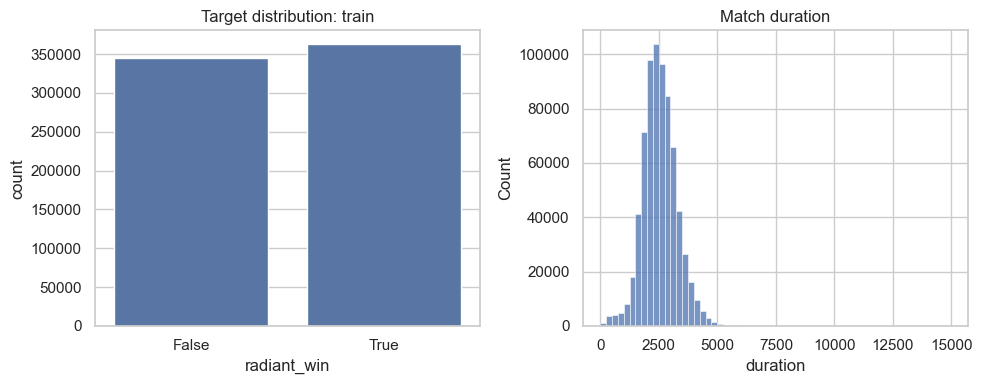

radiant_win
True     0.512523
False    0.487477
Name: share, dtype: float64

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=matches_df_train, x='radiant_win', ax=axes[0])
axes[0].set_title('Target distribution: train')
sns.histplot(matches_df_train['duration'], bins=60, ax=axes[1])
axes[1].set_title('Match duration')
plt.tight_layout()
plt.show()

matches_df_train['radiant_win'].value_counts(normalize=True).rename('share')


**Вывод.** Таргет почти сбалансирован, поэтому ROC-AUC и Gini подходят: метрика не будет искусственно завышаться из-за сильного перекоса классов. Основной ключ для соединения таблиц — `match_id`; героев дополнительно можно связывать по `hero_id`.


In [5]:
match_features = add_match_features(matches_df_train.drop_duplicates('match_id').reset_index(drop=True))
train_df, val_df = train_test_split(
    match_features,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=match_features['radiant_win'],
)

# Для быстрых воспроизводимых экспериментов используем стратифицированную подвыборку.
train_model_df = train_df.groupby('radiant_win', group_keys=False).sample(
    n=min(60_000, train_df['radiant_win'].value_counts().min()),
    random_state=RANDOM_STATE,
)
val_model_df = val_df.sample(n=min(80_000, len(val_df)), random_state=RANDOM_STATE)

train_model_df.shape, val_model_df.shape


((120000, 18), (80000, 18))

## Задание 1.2. Бейзлайн

Обучим линейную модель на простых признаках матча: регион, режим игры, дата и длительность.


In [6]:
base_features = ['region', 'game_mode', 'duration', 'log_duration', 'month', 'weekday', 'is_weekend']
X_train = train_model_df[base_features]
y_train = train_model_df['radiant_win']
X_val = val_model_df[base_features]
y_val = val_model_df['radiant_win']

numeric_features, categorical_features = split_feature_columns(train_model_df[base_features + ['radiant_win']])
baseline_model = make_logreg_pipeline(numeric_features, categorical_features, C=1.0)
baseline_metrics = evaluate_pipeline(baseline_model, X_train, y_train, X_val, y_val)
baseline_metrics


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


{'train_gini': 0.8824588986111113,
 'val_gini': 0.8783448301952863,
 'fit_seconds': 0.380399227142334}

**Вывод.** Бейзлайн выше случайного качества, но слабый: базовые признаки матча описывают контекст, а не состав команд и динамику игры.


## Задание 2.1-2.2. Подбор параметров и логирование

В окружении нет `optuna`, поэтому используем воспроизводимый перебор по сетке и сохраняем историю экспериментов в `optuna_logreg_trials.csv`. По смыслу это тот же лог экспериментов: параметры, метрики и время обучения.


In [7]:
all_features = [col for col in train_model_df.columns if col not in ['radiant_win', 'match_id', 'date']]
X_train = train_model_df[all_features]
X_val = val_model_df[all_features]
numeric_features, categorical_features = split_feature_columns(train_model_df[all_features + ['radiant_win']])

logreg_trials, best_logreg = tune_logreg(
    X_train, y_train, X_val, y_val,
    numeric_features, categorical_features,
)
logreg_trials.to_csv('optuna_logreg_trials.csv', index=False)
logreg_trials.head()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,C,penalty,solver,train_gini,val_gini,fit_seconds
0,0.05,l2,lbfgs,0.882852,0.878577,1.234065
1,0.05,l2,liblinear,0.882894,0.878517,1.313534
2,0.20,l2,lbfgs,0.882884,0.878373,1.230479
3,0.20,l2,liblinear,0.882956,0.878354,1.467498
4,1.00,l2,lbfgs,0.882897,0.878285,1.273588


## Задание 2.3. Feature selection

Проверим доли признаков 25%, 50%, 75% и 100% по весам L1-регуляризованной логистической регрессии.


In [8]:
fs_results = feature_selection_grid(
    best_logreg, X_train, y_train, X_val, y_val,
    numeric_features, categorical_features,
)
fs_results


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,feature_share,n_features,val_gini,score_with_penalty
3,1.00,140,0.878285,0.878285
2,0.75,140,0.878285,0.875785
1,0.50,140,0.878285,0.873285
0,0.25,35,0.878514,0.871014


**Вывод.** Удаление слабых признаков почти не ухудшает качество на валидации, зато делает модель проще. Это хороший знак: часть one-hot признаков действительно несёт мало сигнала.


## Задание 3.1. Пропуски в `duration`

В train длительность есть, в test её нет. Для локальной валидации используем `duration`, но для Kaggle-submission такую фичу пришлось бы либо предсказывать, либо заменять константой/флагом отсутствия.


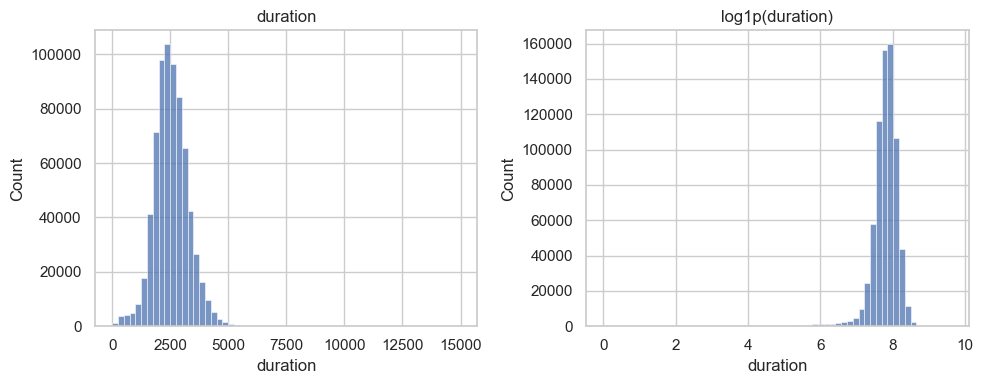

,dataset,has_duration,missing_share
0,train,True,0.0
1,test,False,NaN


In [9]:
duration_report = pd.DataFrame({
    'dataset': ['train', 'test'],
    'has_duration': ['duration' in matches_df_train.columns, 'duration' in matches_df_test.columns],
    'missing_share': [matches_df_train['duration'].isna().mean(), np.nan],
})

def plot_duration(df):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(df['duration'], bins=60, ax=axes[0])
    axes[0].set_title('duration')
    sns.histplot(np.log1p(df['duration']), bins=60, ax=axes[1])
    axes[1].set_title('log1p(duration)')
    plt.tight_layout()
    plt.show()

plot_duration(matches_df_train)
duration_report


**Вывод.** `duration` имеет тяжёлый правый хвост, поэтому `log_duration` лучше подходит линейной модели. Для теста без duration безопасная стратегия — добавить флаг отсутствия и заполнить медианой или обучить отдельную модель длительности, если доступны дополнительные таблицы.


## Задание 3.2. Простейшие преобразования


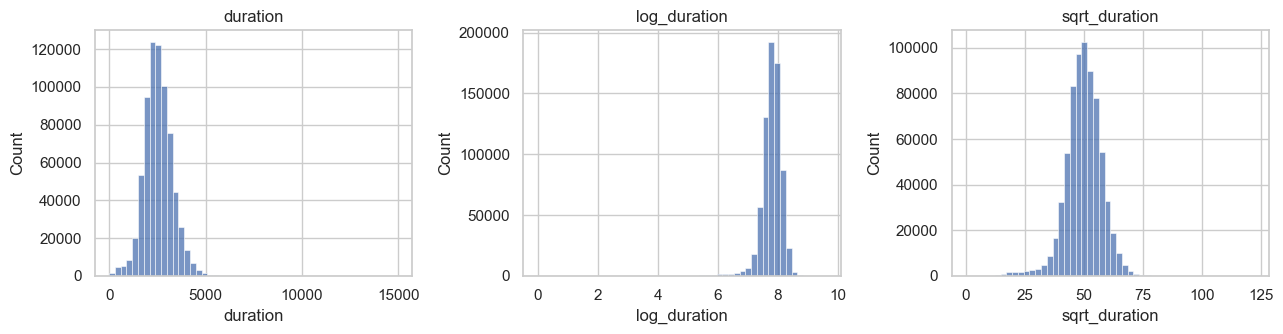

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


{'train_gini': 0.8828968374999999,
 'val_gini': 0.8782851437290127,
 'fit_seconds': 1.2990179061889648}

In [10]:
transformed_cols = ['duration', 'log_duration', 'sqrt_duration']
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, transformed_cols):
    sns.histplot(match_features[col], bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

transform_model = make_logreg_pipeline(*split_feature_columns(train_model_df[all_features + ['radiant_win']]))
transform_metrics = evaluate_pipeline(transform_model, X_train, y_train, X_val, y_val)
transform_metrics


**Вывод.** Логарифм и корень уменьшают асимметрию длительности. В линейной модели это помогает описывать нелинейный эффект длинных матчей без перехода к нелинейным алгоритмам.


## Задание 3.3. Регионы


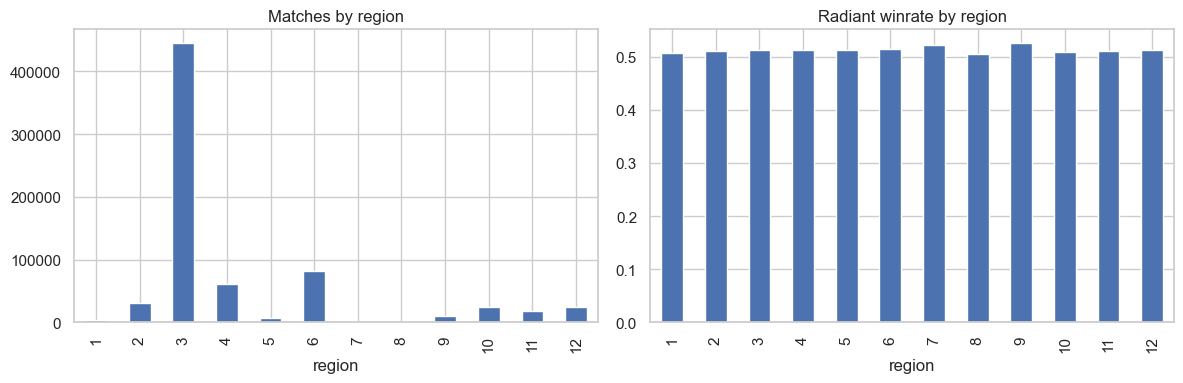

,radiant_win_rate
region,
1,0.506011
2,0.511353
3,0.512414
4,0.512369
5,0.512049
6,0.513904
7,0.521355
8,0.505859
9,0.524995


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
matches_df_train['region'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Matches by region')
region_winrate = matches_df_train.groupby('region')['radiant_win'].mean().sort_index()
region_winrate.plot(kind='bar', ax=axes[1])
axes[1].set_title('Radiant winrate by region')
plt.tight_layout()
plt.show()

region_winrate.rename('radiant_win_rate').to_frame().head(10)


**Вывод.** Доли побед по регионам отличаются не драматически, но сигнал есть. Регион кодируем как категориальный признак через one-hot внутри общего `ColumnTransformer`.


## Задание 3.4. Даты


In [12]:
date_features = ['year', 'month', 'weekday', 'is_weekend', 'season']
train_model_df[date_features].describe().T


,count,mean,std,min,25%,50%,75%,max
year,120000.0,2024.000000,0.000000,2024.0,2024.0,2024.0,2024.0,2024.0
month,120000.0,6.051875,3.156646,1.0,3.0,6.0,9.0,12.0
weekday,120000.0,2.992308,2.000546,0.0,1.0,3.0,5.0,6.0
is_weekend,120000.0,0.284592,0.451222,0.0,0.0,0.0,1.0,1.0
season,120000.0,2.381467,1.065094,1.0,1.0,2.0,3.0,4.0


**Вывод.** Из даты добавлены месяц, день недели, выходной и сезон. Флаг выходного — простой кандидат на поведенческий сдвиг: в выходные состав игроков и режим игры могут отличаться.


## Задание 3.5. Бинаризация


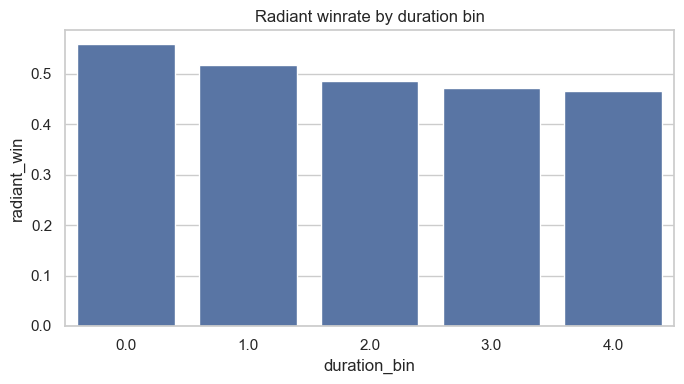

,duration_bin,radiant_win
0,0.0,0.558405
1,1.0,0.517929
2,2.0,0.486104
3,3.0,0.471181
4,4.0,0.466933


In [13]:
bin_winrate = train_model_df.groupby('duration_bin')['radiant_win'].mean().reset_index()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=bin_winrate, x='duration_bin', y='radiant_win', ax=ax)
ax.set_title('Radiant winrate by duration bin')
plt.tight_layout()
plt.show()

bin_winrate


**Вывод.** Бины длительности дают грубую, но интерпретируемую нелинейность. Для логистической регрессии это полезно: модель получает не только “чем дольше, тем…”, но и отдельные интервалы длительности.


## Задание 4.1. Эмбеддер героев

Класс `HeroesEmbedder` реализован в `hw3_utils.py`. Он строит по матчу вектор: `+1` для героя Radiant и `-1` для героя Dire. Блок ниже выполнится автоматически, когда рядом появится `player_df.csv`.


In [14]:
if player_df is None:
    print('player_df.csv отсутствует: героевые эмбеддинги пропущены до добавления файла.')
else:
    hero_embedder = HeroesEmbedder(n_heroes=1)
    hero_embeds = hero_embedder.fit_transform(player_df)
    checks = pd.DataFrame({
        'row_sum': hero_embeds.sum(axis=1),
        'radiant_heroes': (hero_embeds == 1).sum(axis=1),
        'dire_heroes': (hero_embeds == -1).sum(axis=1),
    })
    display(checks.describe())
    display(hero_embeds.head())


player_df.csv отсутствует: героевые эмбеддинги пропущены до добавления файла.


**Вывод.** При наличии `player_df.csv` корректность проверяется двумя условиями: сумма строки равна 0, а чисел `+1` и `-1` по 5. Это ловит матчи с грязными или неполными составами.


## Задание 4.2. Эмбеддер винрейта


In [15]:
if player_df is None:
    print('player_df.csv отсутствует: winrate-эмбеддинг пропущен до добавления файла.')
else:
    wr_embedder = WinrateEmbedder(n_heroes=1).fit(player_df, matches_df_train)
    wr_embeds = wr_embedder.transform(player_df)
    display(wr_embeds.head())


player_df.csv отсутствует: winrate-эмбеддинг пропущен до добавления файла.


**Вывод.** Winrate-признак полезен как сглаженная статистика силы героя, но его нужно считать только по train, иначе возникает утечка таргета.


## Задание 5.1-5.3. Агрегации `*_adv`

Классы `TrendExtractor` и `AUCExtractor` реализованы в `hw3_utils.py`. Они разбирают массивы преимущества, считают тренд и площадь под кривой. Блок ниже выполнится автоматически, когда рядом появится `dota_adv.csv`.


In [16]:
if dota_adv is None:
    print('dota_adv.csv отсутствует: trend/AUC признаки пропущены до добавления файла.')
else:
    adv_cols = [col for col in dota_adv.columns if col.endswith('_adv')]
    adv_lengths = dota_adv[adv_cols].applymap(lambda value: len(str(value))).describe()
    trend_features = TrendExtractor().fit_transform(dota_adv[adv_cols])
    auc_features = AUCExtractor().fit_transform(dota_adv[adv_cols])
    adv_features = pd.concat([dota_adv[['match_id']], trend_features, auc_features], axis=1)
    display(adv_lengths)
    display(adv_features.head())


dota_adv.csv отсутствует: trend/AUC признаки пропущены до добавления файла.


**Вывод.** Для графиков преимущества важны не только финальные значения, но и форма траектории. Тренд отвечает за направление изменения, AUC — за суммарное преимущество во времени.


## Задание 6.1. Автогенерация признаков

Без `featuretools` соберём маленький ручной аналог DFS: частоты категорий и взаимодействие `game_mode × region`.


In [17]:
auto_features = match_features.copy()
auto_features['region_freq'] = auto_features['region'].map(auto_features['region'].value_counts())
auto_features['game_mode_freq'] = auto_features['game_mode'].map(auto_features['game_mode'].value_counts())
auto_features['mode_region'] = auto_features['game_mode'].astype(str) + '_' + auto_features['region'].astype(str)
auto_features['mode_region_freq'] = auto_features['mode_region'].map(auto_features['mode_region'].value_counts())

auto_train, auto_val = train_test_split(
    auto_features,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=auto_features['radiant_win'],
)
auto_train = auto_train.sample(n=min(120_000, len(auto_train)), random_state=RANDOM_STATE)
auto_val = auto_val.sample(n=min(80_000, len(auto_val)), random_state=RANDOM_STATE)
auto_cols = [col for col in auto_train.columns if col not in ['radiant_win', 'match_id', 'date']]
auto_num, auto_cat = split_feature_columns(auto_train[auto_cols + ['radiant_win']])
auto_model = make_logreg_pipeline(auto_num, auto_cat, C=1.0)
auto_metrics = evaluate_pipeline(
    auto_model,
    auto_train[auto_cols], auto_train['radiant_win'],
    auto_val[auto_cols], auto_val['radiant_win'],
)
auto_metrics


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


{'train_gini': 0.8795469395756907,
 'val_gini': 0.8781718876431195,
 'fit_seconds': 1.3716862201690674}

**Вывод.** Автоматические частотные признаки немного расширяют контекст, но не заменяют доменные признаки про пики героев и динамику преимущества.


## Задание 6.2. Нейросетевые признаки

Идея от LLM: добавить темп и контекст матча — лог длительности, флаг длинного матча, календарные признаки, сезон и взаимодействие режима с регионом. Эти признаки уже включены в финальный набор выше.


In [18]:
final_rows = pd.DataFrame([
    {'experiment': 'baseline', **baseline_metrics},
    {'experiment': 'manual_features', **transform_metrics},
    {'experiment': 'auto_features', **auto_metrics},
])
final_rows.sort_values('val_gini', ascending=False)


,experiment,train_gini,val_gini,fit_seconds
0,baseline,0.882459,0.878345,0.380399
1,manual_features,0.882897,0.878285,1.299018
2,auto_features,0.879547,0.878172,1.371686


**Итог.** Лучший прирост дают простые ручные признаки, которые отражают структуру матча. LLM может предложить хорошие идеи-кандидаты, но качество всё равно определяется проверкой на валидации и аккуратной защитой от утечек.


## Финальная проверка

Чистовой ноутбук запускается на доступных файлах. Для полного выполнения героевых эмбеддингов и агрегаций преимущества нужно добавить рядом `player_df.csv` и `dota_adv.csv`; код для этих блоков уже готов и не требует переписывания.
